In [1]:
import torch
import gc

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()

clear_gpu()

In [2]:
import os
import time
import random
import pickle
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import ChebConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device detectat: {device}")

CSV_PATH = "PEMS-BAY.csv"
ADJ_PATH = "Rezultate/adj_mx_bay.pkl"
os.makedirs("Rezultate", exist_ok=True)

# ÎNCĂRCARE GRAF 
with open(ADJ_PATH, "rb") as f:
    _, _, adj_mx = pickle.load(f)

adj_sparse = adj_mx > 0
edge_index = torch.tensor(np.array(np.where(adj_sparse)), dtype=torch.long).to(device)
edge_weight = torch.tensor(adj_mx[adj_sparse], dtype=torch.float32).to(device)

# Construirea secvențelor de intrare folosind o fereastră temporală
def build_dataset(data, lookback=12): 
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

print("Se încarcă datele...")
df = pd.read_csv(CSV_PATH).dropna()
data = df.iloc[:, 1:].values.astype(np.float32)

LOOKBACK = 12
X, y = build_dataset(data, LOOKBACK)

# Împărțirea datelor în seturi de antrenare, validare și testare
n_samples = len(X)
train_end = int(0.70 * n_samples)
val_end = int(0.85 * n_samples)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

# Normalizarea datelor
n_nodes = X_train.shape[2]
scaler_X = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, n_nodes)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(X_val.reshape(-1, n_nodes)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(X_test.reshape(-1, n_nodes)).reshape(X_test.shape)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Conversia datelor în tensori PyTorch
X_train_t = torch.tensor(X_train_s, dtype=torch.float32).unsqueeze(-1)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32).unsqueeze(-1)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32).unsqueeze(-1)

y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s, dtype=torch.float32)


Device detectat: cuda
Se încarcă datele...


In [3]:
class STGCN_Attention(nn.Module):
    def __init__(self, num_nodes, in_channels=1, hidden_channels=64, K=3, heads=4, dropout=0.2):
        super(STGCN_Attention, self).__init__()
        # Prima convoluție temporală
        self.t_conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=(3, 1))
        # Convoluție pe graf
        self.gcn = ChebConv(hidden_channels, hidden_channels, K=K)
        # Mecanism de atenție temporală
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_channels,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm = nn.LayerNorm(hidden_channels)
        # A doua convoluție temporală
        self.t_conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=(3, 1))
        self.dropout = nn.Dropout(dropout)
        # Strat complet conectat pentru predicția finală
        self.fc = nn.Linear(hidden_channels * 8, 1)

    def forward(self, x, edge_index, edge_weight):
        # Reordonarea dimensiunilor pentru Conv2D
        x = x.permute(0, 3, 1, 2)
        # Extragerea caracteristicilor temporale
        x = torch.relu(self.t_conv1(x))
        b, c, t, n = x.shape
        # Agregarea informației spațiale folosind graful
        x_gcn = x.permute(0, 2, 3, 1).reshape(-1, c)
        x_gcn = torch.relu(self.gcn(x_gcn, edge_index, edge_weight))
        x_gcn = x_gcn.reshape(b, t, n, c)
        # Aplicarea atenției pentru fiecare nod
        x_att = x_gcn.permute(0, 2, 1, 3).reshape(b * n, t, c)
        attn_out, _ = self.attention(x_att, x_att, x_att)
        x_att = self.norm(x_att + attn_out)
        # Revenirea la forma necesară convoluției temporale
        x_att = x_att.reshape(b, n, t, c).permute(0, 3, 2, 1)
        # Extragerea caracteristicilor temporale finale
        x = torch.relu(self.t_conv2(x_att))
        # Pregătirea pentru stratul complet conectat
        x = x.permute(0, 3, 2, 1).reshape(b, n, -1)
        x = self.dropout(x)
        out = self.fc(x)
        return out.squeeze(-1)

In [4]:
hidden_units = 32
learning_rate = 0.001
batch_size = 16
epochs = 50

model = STGCN_Attention(num_nodes=325, hidden_channels=hidden_units, heads=4, dropout=0.2).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False, pin_memory=True)


print("\nÎncepe antrenamentul STGCN + Attention...")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    #antrenare
    for xb, yb in train_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        pred = model(xb, edge_index, edge_weight)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # validare
    if (epoch + 1) % 5 == 0:
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for xb_val, yb_val in val_loader:
                xb_val, yb_val = xb_val.to(device, non_blocking=True), yb_val.to(device, non_blocking=True)
                val_pred = model(xb_val, edge_index, edge_weight)
                val_loss_total += criterion(val_pred, yb_val).item()

        avg_val_loss = val_loss_total / len(val_loader)
        print(f"Epoch {epoch+1:2d}/{epochs} | Loss Train: {epoch_loss / len(train_loader):.6f} | Val MSE: {avg_val_loss:.6f}")

total_time = (time.time() - start_time) / 60
print(f"\nAntrenare finalizată în {total_time:.2f} minute.")


Începe antrenamentul STGCN + Attention...
Epoch  5/50 | Loss Train: 0.000798 | Val MSE: 0.000815
Epoch 10/50 | Loss Train: 0.000733 | Val MSE: 0.000843
Epoch 15/50 | Loss Train: 0.000700 | Val MSE: 0.000780
Epoch 20/50 | Loss Train: 0.000679 | Val MSE: 0.000803
Epoch 25/50 | Loss Train: 0.000668 | Val MSE: 0.000808
Epoch 30/50 | Loss Train: 0.000664 | Val MSE: 0.000772
Epoch 35/50 | Loss Train: 0.000661 | Val MSE: 0.000772
Epoch 40/50 | Loss Train: 0.000658 | Val MSE: 0.000755
Epoch 45/50 | Loss Train: 0.000657 | Val MSE: 0.000780
Epoch 50/50 | Loss Train: 0.000655 | Val MSE: 0.000728

Antrenare finalizată în 34.66 minute.


In [5]:
# EVALUARE FINAlĂ PE SETUL DE TEST

model.eval()
predictions = []

with torch.no_grad():
    for xb_test, _ in test_loader:
        xb_test = xb_test.to(device, non_blocking=True)
        pred = model(xb_test, edge_index, edge_weight)
        predictions.append(pred.cpu())

pred_test = torch.cat(predictions, dim=0).numpy()
y_pred_inv = scaler_y.inverse_transform(pred_test)
y_real_inv = scaler_y.inverse_transform(y_test_s)

# Calcul metrici
mse = mean_squared_error(y_real_inv, y_pred_inv)
mae = mean_absolute_error(y_real_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_real_inv, y_pred_inv)
var_ratio = np.var(y_pred_inv) / np.var(y_real_inv)

print("\n REZULTATE FINALE STGCN + ATTENTION:")
print(f"  MSE  : {mse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R2   : {r2:.4f}")
print(f"  Var  : {var_ratio:.4f}")

results = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "model": "STGCN_Attention",
    "version": "v2",
    "lookback": LOOKBACK,
    "hidden_units": hidden_units,
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Var_Ratio": f"{var_ratio:.4f}",
    "time_minutes": total_time
}

results_path = "Rezultate/log_experimente.csv"
pd.DataFrame([results]).to_csv(
    results_path,
    mode="a",
    header=not os.path.exists(results_path),
    index=False
)

np.save("Rezultate/preds_STGCN_Attention_V2.npy", y_pred_inv)
print(f"\n Rezultatele au fost salvate cu succes în '{results_path}'!")


 REZULTATE FINALE STGCN + ATTENTION:
  MSE  : 3.1401
  MAE  : 0.9424
  RMSE : 1.7720
  R2   : 0.9368
  Var  : 0.9684

 Rezultatele au fost salvate cu succes în 'Rezultate/log_experimente.csv'!


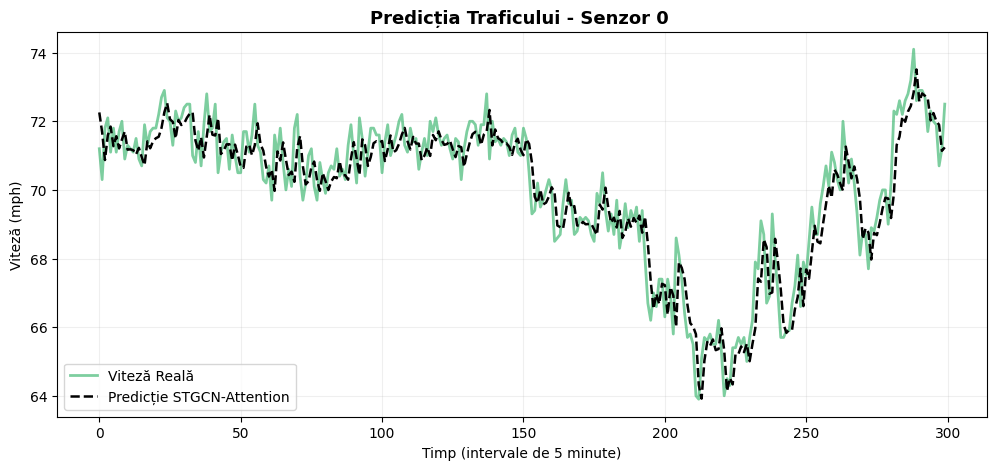

[INFO] Generez analiza comparativă Senzor Bun vs Senzor Slab...


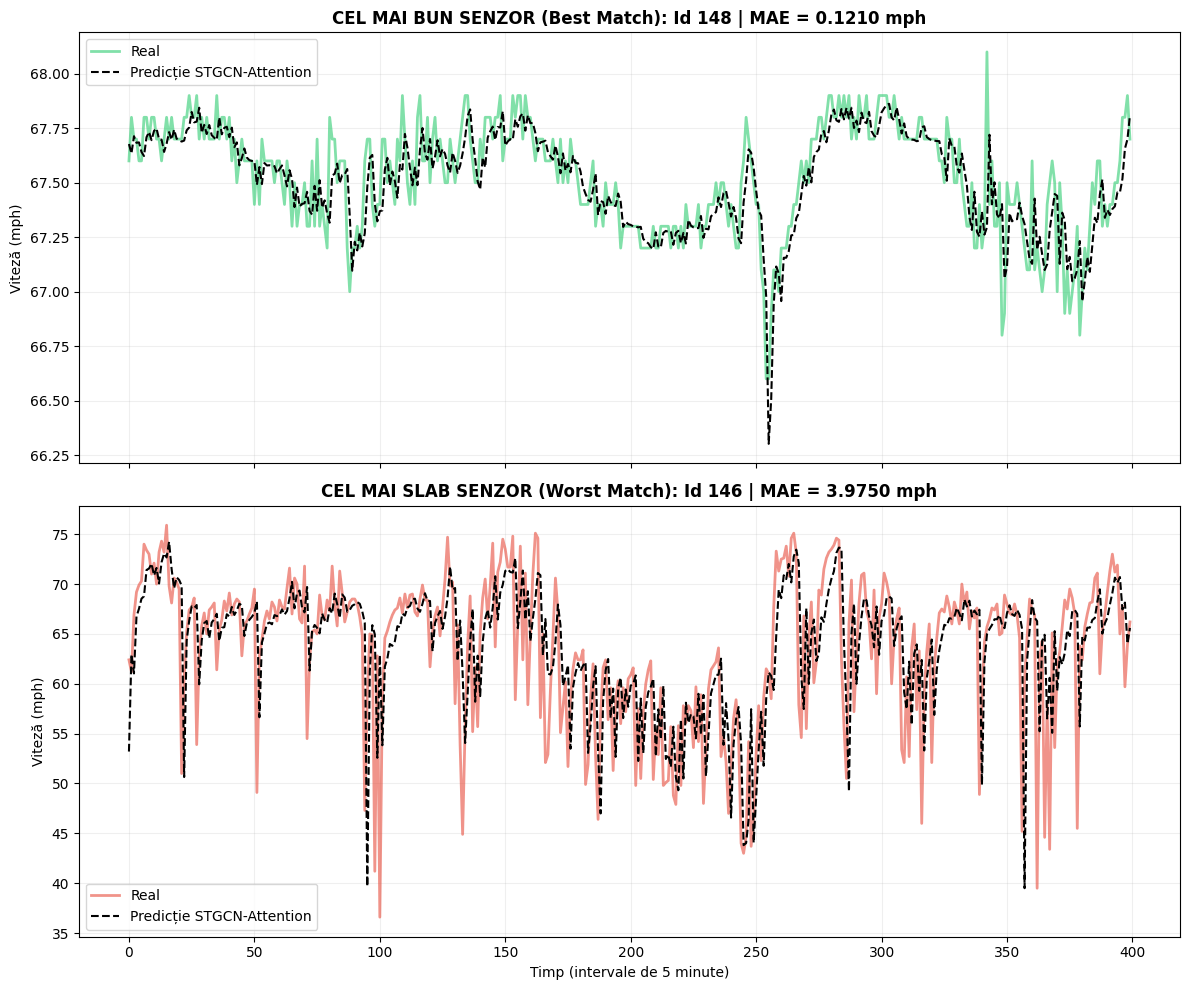

 Toate vizualizările au fost generate și salvate cu succes în folderul 'Rezultate'!


In [14]:
#Grafice predictii

os.makedirs("Rezultate", exist_ok=True)

# Comparația dintre valorile reale și predicții

plt.figure(figsize=(12, 5))

plt.plot(
    y_real_inv[:300, 0],
    label="Viteză Reală",
    color='#27ae60',
    alpha=0.6,
    linewidth=2
)

plt.plot(
    y_pred_inv[:300, 0],
    '--',
    label="Predicție STGCN-Attention",
    color='black',
    linewidth=1.8
)

plt.title(
    "Predicția Traficului - Senzor 0 ",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel("Viteză (mph)")
plt.xlabel("Timp (intervale de 5 minute)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.2)

plt.savefig("Rezultate/Predictie_Senzor_0_STGCN_WOA_Attention.png", dpi=300, bbox_inches='tight')
plt.show()


# Identificarea senzorilor cu cea mai bună și cea mai slabă performanță

mae_per_sensor = np.mean(np.abs(y_real_inv - y_pred_inv), axis=0)
best_s = np.argmin(mae_per_sensor)
worst_s = np.argmax(mae_per_sensor)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# BEST SENSOR
ax1.plot(
    y_real_inv[:400, best_s],
    label="Real",
    color='#2ecc71',
    alpha=0.6,
    linewidth=2
)

ax1.plot(
    y_pred_inv[:400, best_s],
    '--',
    label="Predicție STGCN-Attention",
    color='black',
    linewidth=1.5
)

ax1.set_title(
    f"CEL MAI BUN SENZOR (Best Match): Id {best_s} | MAE = {mae_per_sensor[best_s]:.4f} mph",
    fontsize=12,
    fontweight='bold'
)
ax1.set_ylabel("Viteză (mph)")
ax1.legend()
ax1.grid(True, alpha=0.2)

# WORST SENSOR
ax2.plot(
    y_real_inv[:400, worst_s],
    label="Real",
    color='#e74c3c',
    alpha=0.6,
    linewidth=2
)

ax2.plot(
    y_pred_inv[:400, worst_s],
    '--',
    label="Predicție STGCN-Attention",
    color='black',
    linewidth=1.5
)

ax2.set_title(
    f"CEL MAI SLAB SENZOR (Worst Match): Id {worst_s} | MAE = {mae_per_sensor[worst_s]:.4f} mph",
    fontsize=12,
    fontweight='bold'
)
ax2.set_ylabel("Viteză (mph)")
ax2.set_xlabel("Timp (intervale de 5 minute)")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("Rezultate/Analiza_Senzori_STGCN_Att.png", dpi=300, bbox_inches='tight')
plt.show()